## در این مثال داده های شبیه سازی شده از یک برج تقطیر استفاده شده است. داده ها شامل اطلاعات 16 سنسور و نسبت مولی TX, HX می باشد هدف یافتن مدل برای پیش بینی دو نسبت مولی است.
دیتاست از طریق زیر دریافت و پوشه کاری قرار داده شود.

https://github.com/hojatollahgholami/AI-in-Oil-and-gas-industry/blob/main/ex3-6/DistillationColumn.xlsx

جهت اطلاعات بیشتر ستون ها عبارت هستند از:

Sensor1 : Liquid Percentage in Condenser

Sensor2: Condenser Pressure

Sensor3: Liquid Percentage in Reboiler

Sensor4 & Sensor5: Mass Flow Rate in Feed Flow and Top Outlet Stream

Sensor6: Net Mass Flow in main tower

Sensor7: Mole Fraction HX at reboiler

Sensor8: HX Mole Fraction in Top Outler Stream

Sensor9 & Sensor10: Feed Mole Fraction

Sensor11: Feed Tray Temperature

Sensor12: Main Tower Pressure

Sensor13: Bottom Tower Pressure

Sensor14: Top Tower Pressure

Sensor15: Reflux Ratio

Sensor16: Duties Summary

MoleFraction TX

MoleFraction HX

## نصب کتابخانه های مورد نیاز

In [1]:
!pip install torch torchvision arabic-reshaper python-bidi openpyxl

## فراخوانی کتابخانه های مورد نیاز

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

from arabic_reshaper import reshape
from bidi.algorithm import get_display

## تعریف پارامترها و توابع کمکی

In [3]:
# تابع تبدیل متن فارسی برای نمایش در نمودارها
def fa(text):
    reshaped_text = reshape(text)
    return get_display(reshaped_text)

# تنظیمات فارسی نویسی
plt.rcParams["font.family"] = 'Adobe Arabic' 
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams['font.size'] = 16

## بارگزاری دیتاست و بررسی

In [4]:
# خواندن دیتاست
# =======================
df = pd.read_excel("DistillationColumn.xlsx")
print("ابعاد داده:", df.shape)
print(df.head())

# بررسی اولیه 
# =======================
print(df.info())
print(df.describe().T)

# پر کردن مقادیر گمشده
df = df.fillna(method="ffill").fillna(method="bfill")

ابعاد داده: (961, 19)
   Time    Sensor1     Sensor2    Sensor3      Sensor4      Sensor5  \
0     0  49.718959  101.414959  49.718959  3693.858959  6695.368959   
1    30  49.561845  100.962045  49.541545  3712.947045  6629.637045   
2    60  50.189365  101.490865  50.145165  3718.008865  6692.598865   
3    90  50.183496  101.403296  50.142796  3721.819296  6702.869296   
4   120  50.428793  101.603693  50.406093  3724.444693  6710.444693   

       Sensor6      Sensor7   Sensor8   Sensor9  Sensor10   Sensor11  \
0  2924.818959  1048.588959  0.054394  0.501001  0.498999  76.803959   
1  2767.487045  1046.987045  0.054233  0.501001  0.498999  76.437645   
2  2763.018865  1050.988865  0.053941  0.501001  0.498999  77.041465   
3  2754.009296  1051.449296  0.053968  0.501001  0.498999  77.016096   
4  2744.244693  1052.674693  0.054121  0.501001  0.498999  77.252293   

     Sensor12    Sensor13   Sensor14  Sensor15  Sensor16  MoleFractionTX  \
0  104.148959  110.216959  67.038059  0.79

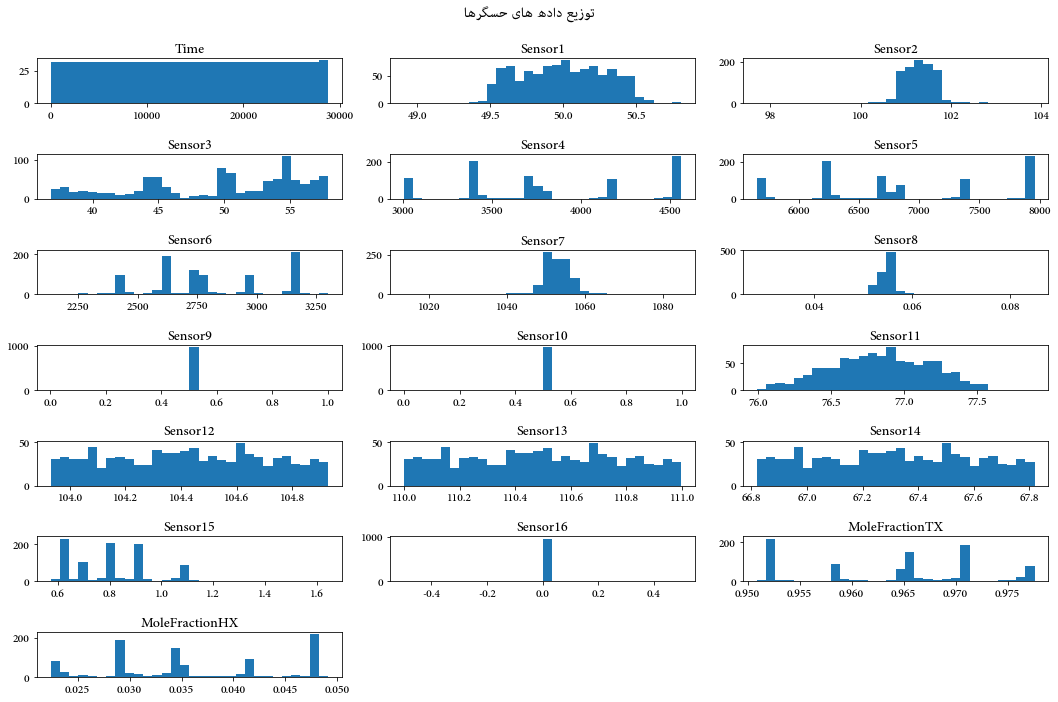

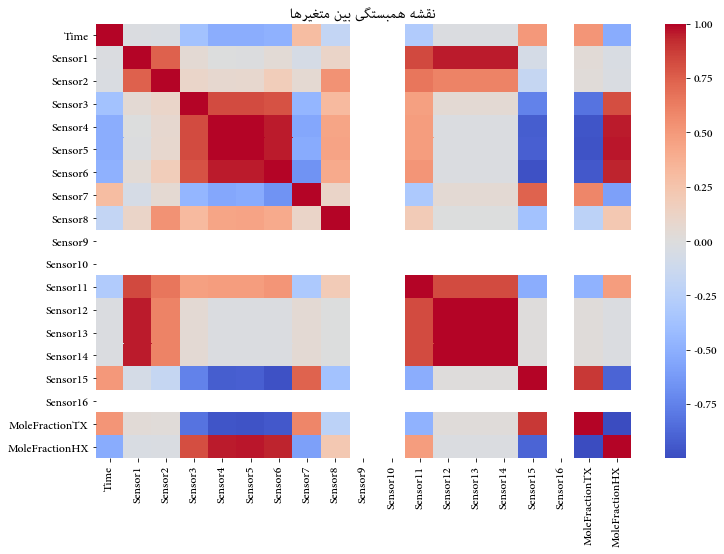

In [5]:
# توزیع داده ها
fig, axes = plt.subplots(nrows=len(df.columns)//3 + 1, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, column in enumerate(df.columns):
    axes[i].hist(df[column], bins=30)
    axes[i].set_title(column)

# مخفی کردن محورهای بلااستفاده برای نمایش بهتر
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(fa("توزیع داده های حسگرها"))
plt.tight_layout()
plt.show()


# بررسی همبستگی
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title(fa("نقشه همبستگی بین متغیرها"))
plt.show()

## تحلیل اکتشافی

In [6]:
target_col = df.columns[-2:]   # دو ستون آخر اهداف است
sensor_cols = df.columns[1:-2]
print(target_col)
print(sensor_cols)

Index(['MoleFractionTX', 'MoleFractionHX'], dtype='object')
Index(['Sensor1', 'Sensor2', 'Sensor3', 'Sensor4', 'Sensor5', 'Sensor6',
       'Sensor7', 'Sensor8', 'Sensor9', 'Sensor10', 'Sensor11', 'Sensor12',
       'Sensor13', 'Sensor14', 'Sensor15', 'Sensor16'],
      dtype='object')


In [7]:
X_raw = df[sensor_cols].values
y_raw = df[target_col].values


# نرمال سازی
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)


# پنجره های زمانی
window_size = 10
def make_windows(X, y, window):
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X[i:i+window].flatten())
        ys.append(y[i+window])
    return np.array(Xs), np.array(ys)


X, y = make_windows(X_scaled, y_raw, window_size)


# تقسیم داده
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)

# تبدیل به Tensor
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val, dtype=torch.float32)
y_val_t   = torch.tensor(y_val, dtype=torch.float32)


train_ds = TensorDataset(X_train_t, y_train_t)
val_ds   = TensorDataset(X_val_t, y_val_t)


train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False)

In [8]:
#  مدل MLP در PyTorch
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 2)
        self.dropout = nn.Dropout(0.2)
        self.relu = nn.ReLU()
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x


input_dim = X_train.shape[1]
model = MLP(input_dim)


criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [9]:
# آموزش
# =======================
n_epochs = 100
train_losses, val_losses = [], []


for epoch in range(n_epochs):
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_loss = np.mean(batch_losses)


    # اعتبارسنجی
    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_t)
        val_loss = criterion(val_preds, y_val_t).item()
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)


    if epoch % 10 == 0:
        print(f"دور {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")

دور 0: train_loss=0.1236, val_loss=0.0585
دور 10: train_loss=0.0088, val_loss=0.0020
دور 20: train_loss=0.0064, val_loss=0.0007
دور 30: train_loss=0.0055, val_loss=0.0006
دور 40: train_loss=0.0052, val_loss=0.0006
دور 50: train_loss=0.0043, val_loss=0.0004
دور 60: train_loss=0.0041, val_loss=0.0004
دور 70: train_loss=0.0036, val_loss=0.0003
دور 80: train_loss=0.0036, val_loss=0.0003
دور 90: train_loss=0.0029, val_loss=0.0001


In [10]:
# ارزیابی
model.eval()
with torch.no_grad():
    y_pred = model(X_val_t).squeeze().numpy()


rmse = np.sqrt(mean_squared_error(y_val, y_pred))
mae = mean_absolute_error(y_val, y_pred)
mape = mean_absolute_percentage_error(y_val, y_pred)


print("RMSE:", rmse)
print("MAE:", mae)
print("MAPE:", mape)

RMSE: 0.015578747406774205
MAE: 0.00970663654839
MAPE: 0.07758231227653743


## مصورسازی

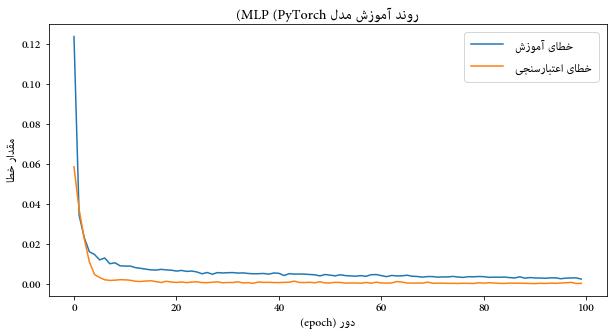

In [11]:
# روند آموزش
plt.figure(figsize=(10,5))
plt.plot(train_losses, label=fa("خطای آموزش"))
plt.plot(val_losses, label=fa("خطای اعتبارسنجی"))
plt.legend()
plt.title(fa("روند آموزش مدل MLP (PyTorch)"))
plt.xlabel(fa("دور (epoch)"))
plt.ylabel(fa("مقدار خطا"))
plt.show()

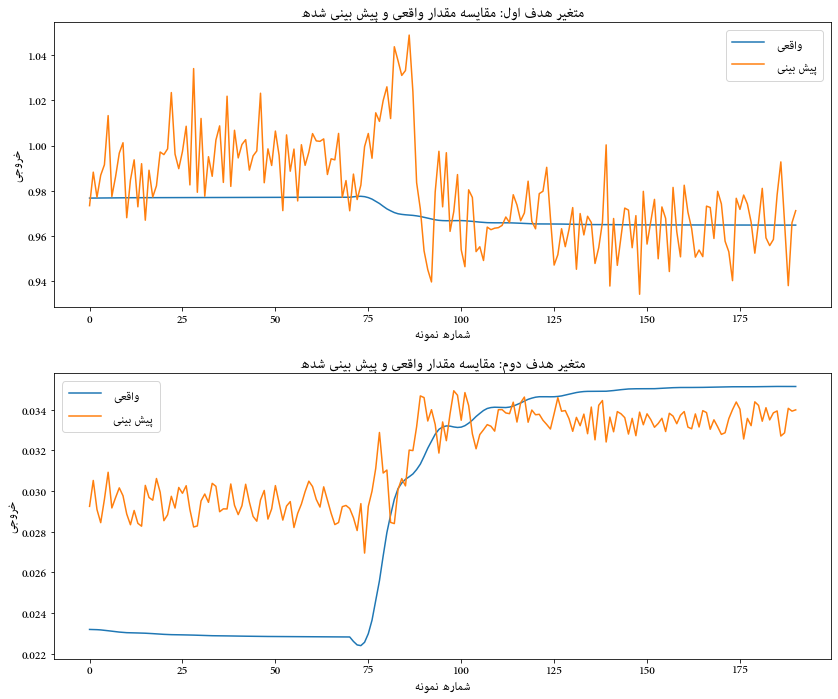

In [12]:
# واقعی vs پیش بینی
# تبدیل تانسور به آرایه در صورت نیاز
y_val_np = y_val_t.numpy() if torch.is_tensor(y_val_t) else y_val
y_pred_np = y_pred.detach().numpy() if torch.is_tensor(y_pred) else y_pred


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# نمایش هدف اول
ax1.plot(y_val_np[:, 0], label=fa("واقعی"))
ax1.plot(y_pred_np[:, 0], label=fa("پیش بینی"))
ax1.legend()
ax1.set_title(fa("متغیر هدف اول: مقایسه مقدار واقعی و پیش بینی شده"))
ax1.set_xlabel(fa("شماره نمونه"))
ax1.set_ylabel(fa("خروجی"))

# نمایش هدف دوم
ax2.plot(y_val_np[:, 1], label=fa("واقعی"))
ax2.plot(y_pred_np[:, 1], label=fa("پیش بینی"))
ax2.legend()
ax2.set_title(fa("متغیر هدف دوم: مقایسه مقدار واقعی و پیش بینی شده"))
ax2.set_xlabel(fa("شماره نمونه"))
ax2.set_ylabel(fa("خروجی"))

plt.tight_layout()
plt.show()

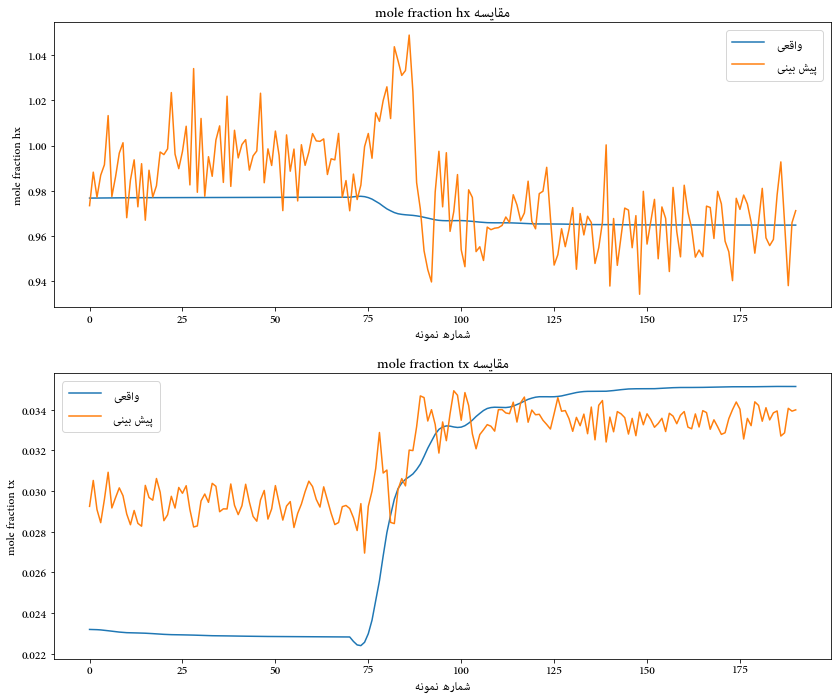

In [13]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))


# هدف اول
ax1.plot(y_val_np[:, 0], label=fa("واقعی"))
ax1.plot(y_pred_np[:, 0], label=fa("پیش بینی"))
ax1.legend()
ax1.set_title(fa("مقایسه mole fraction HX"))
ax1.set_xlabel(fa("شماره نمونه"))
ax1.set_ylabel(fa("mole fraction HX"))


# هدف دوم
ax2.plot(y_val_np[:, 1], label=fa("واقعی"))
ax2.plot(y_pred_np[:, 1], label=fa("پیش بینی"))
ax2.legend()
ax2.set_title(fa("مقایسه mole fraction TX"))
ax2.set_xlabel(fa("شماره نمونه"))
ax2.set_ylabel(fa("mole fraction TX"))

plt.tight_layout()
plt.show()

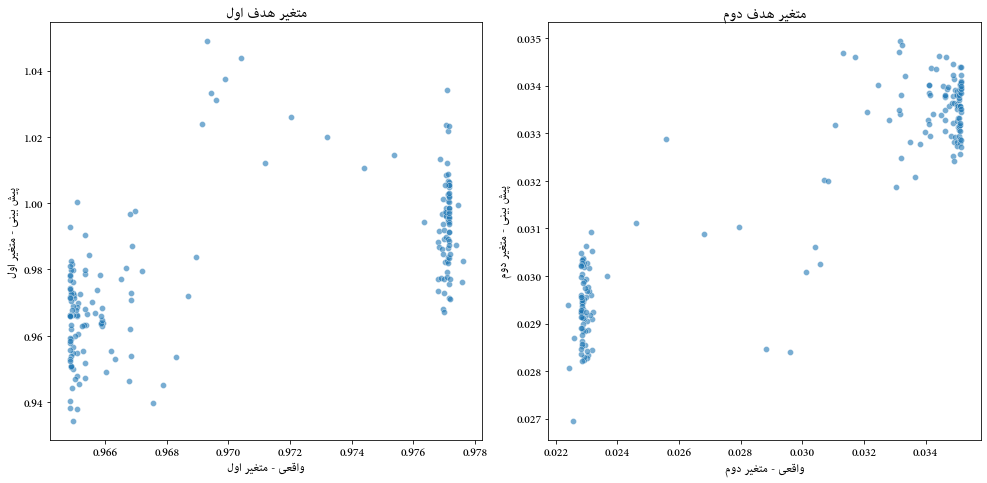

In [14]:
# نمودار پراکندگی
# تبدیل تانسورها به آرایه در صورت نیاز
y_val_np = y_val_t.numpy() if torch.is_tensor(y_val_t) else y_val
y_pred_np = y_pred.detach().numpy() if torch.is_tensor(y_pred) else y_pred


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# نمایش اولین هدف
sns.scatterplot(x=y_val_np[:, 0], y=y_pred_np[:, 0], alpha=0.6, ax=ax1)
ax1.set_xlabel(fa("واقعی - متغیر اول"))
ax1.set_ylabel(fa("پیش بینی - متغیر اول"))
ax1.set_title(fa("متغیر هدف اول"))

# نمایش دومین هدف
sns.scatterplot(x=y_val_np[:, 1], y=y_pred_np[:, 1], alpha=0.6, ax=ax2)
ax2.set_xlabel(fa("واقعی - متغیر دوم"))
ax2.set_ylabel(fa("پیش بینی - متغیر دوم"))
ax2.set_title(fa("متغیر هدف دوم"))

plt.tight_layout()
plt.show()